In [17]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from itertools import product
from tqdm import trange

from cliff_walking.environment import Environment
from cliff_walking.sarsa_agent import SarsaAgent
from cliff_walking.ql_agent import QLearningAgent

In [18]:
environment = Environment((5, 4))

In [23]:
n_agents = 10
n_episodes = 500

s_agents = [SarsaAgent(alpha=0.5, gamma=1, eps=.1, environment=environment) for i in range(n_agents)]
s_rs = [0.0] * n_episodes
q_agents = [QLearningAgent(alpha=0.5, gamma=1, eps=.1, environment=environment) for i in range(n_agents)]
q_rs = [0.0] * n_episodes

for episode_idx in trange(n_episodes):
    for s_agent, q_agent in zip(s_agents, q_agents):
        s_agent.eps -= 0.6 / 500
        q_agent.eps -= 0.6 / 500
        s_rs[episode_idx] += s_agent.run(50) / n_agents
        q_rs[episode_idx] += q_agent.run(50) / n_agents

100%|██████████| 500/500 [00:19<00:00, 25.96it/s]


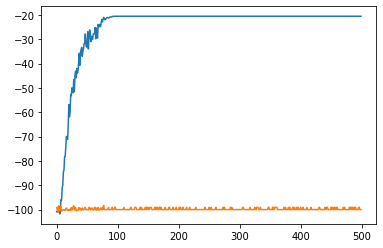

In [24]:
plt.plot(s_rs)
plt.plot(q_rs)

0.0002